# LLM-Driven Personal Financial Assistant

**Technical report and reproducible experiments**

This document accompanies the repository implementation. Each section maps to project design, integration, prompting, domain logic, evaluation and critical analysis.

---


## 1. Title and project overview *(R1, R3, R5)*

### 1.1 System in one paragraph

The **LLM-Driven Personal Financial Assistant** is a Streamlit application that guides users through a **slot-filling dialogue** (`SessionSlots` in `src/dialogue/slots.py`). A local backend (`MockLLMBackend` or `HFLocalBackend`) performs JSON extraction and, when slots are complete, generates a **structured recommendation** validated against `FinancialRecommendation` in `src/finassist/schemas.py`. The design prioritises **grounding** and **auditability**: numeric debt feasibility is not left to the LM alone—it is computed in Python (`src/finassist/debt_calculations.py`) and injected into the recommendation prompt.

### 1.2 Problem statement

Unconstrained chat with a causal LM yields unstable structure and unreliable arithmetic on financial quantities. This project mitigates that through **staged collection**, **schema-constrained generation**, and a **deterministic calculation layer** that the model is instructed to cite—reducing hallucinated payment figures relative to a prompt-only baseline.

### 1.3 Scope

Implemented: Streamlit UI, dialogue state machine, HF local inference with optional 4-bit loading, mock backend for testing, JSON recommendation parsing, debt metrics echo, evaluation fixtures and batch script. **Not** implemented: retrieval (RAG), live market data feeds, or production-grade compliance tooling. Optional: LoRA training (`scripts/train_lora.py`) when data and compute are available.

**Rubric alignment:** problem statement, scope, and defensible claims (what is *in* vs *out* of scope).

**Analysis.** *Rationale:* staged slots give the recommender a **stable, typed profile** instead of noisy chat history. *Benefit:* better JSON validity and traceability for coursework assessment. *Trade-off:* higher user burden and dependence on extraction quality—mitigated by retries and manual Quick edit (`src/app/chat_ui.py`).

---


## 2. System architecture *(R1)*

The codebase separates concerns so the UI does not embed business logic: **orchestration** lives in `DialogueEngine`, **validation** in `validators.py`, and **presentation strings** in `guided_flow.py`.

| Layer | Responsibility | Primary modules |
|------|----------------|-----------------|
| UI | Pages, sidebar, chat | `src/app/streamlit_app.py`, `src/app/chat_ui.py`, `src/app/pages/` |
| Dialogue | State transitions, slot merge, extraction JSON | `src/dialogue/state_machine.py`, `guided_flow.py`, `validators.py` |
| LLM | Generation backends | `src/llm/mock_backend.py`, `hf_local.py` |
| Finance | Metrics, schema parse, justification | `src/finassist/debt_calculations.py`, `schemas.py`, `justification.py` |
| Evaluation | Fixtures → CSV | `src/evaluation/run_eval.py`, `configs/evaluation.yaml` |

### 2.1 Data flow

```mermaid
flowchart LR
  subgraph ui [Streamlit_UI]
    Chat[Chat_page]
  end
  subgraph dlg [DialogueEngine]
    SM[state_machine]
    Slots[SessionSlots]
  end
  subgraph llm [LLM_backend]
    HF[HFLocalBackend]
    Mock[MockLLMBackend]
  end
  subgraph fin [Deterministic_layer]
    Calc[debt_calculations]
    Schema[parse_recommendation_json]
  end
  Chat --> SM
  SM --> HF
  SM --> Mock
  SM --> Calc
  HF --> Schema
  Mock --> Schema
  Calc --> SM
```

Extraction and recommendation are **separate** `generate` calls. Metrics from `build_recommendation_calc_payload` (`src/finassist/debt_calculations.py`) are injected into `src/llm/prompts/recommend.jinja2` only—they do not replace the model's strategy prose, but bound numerical claims.

**Rubric alignment:** modular **system design** and clear separation of UI, dialogue, LLM, and finance layers.

**Analysis.** *Rationale:* separating `DialogueEngine` from Streamlit makes the pipeline **testable** without a browser (`tests/`, notebook cells). *Benefit:* easier marking of “does the NLP core work?” *Trade-off:* more files to navigate; small changes may touch both `state_machine.py` and prompts.

### 2.2 Design decisions (summary)

| Decision | Rationale | Trade-off |
|----------|-----------|------------|
| **Local open instruct models** | Reproducible on student GPUs; no API keys in code | Weaker reasoning than frontier APIs; user must manage HF cache |
| **Deterministic debt floor** (`debt_calculations.py`) | Arithmetic is auditable; LM explains fixed numbers | Principal-only model is unrealistic vs APR-aware amortisation |
| **No project LoRA by default** (`adapter_path: null`) | Baseline works without training run; rubric still documents `train_lora.py` | Domain style not specialised to this coursework JSON |

---


### 2.3 Environment bootstrap *(R6 — reproducibility)*

**Rubric alignment:** **reproducibility** (paths, kernel, parity with CLI).

`project_root()` in `src/utils/config_loader.py` anchors paths to the repository regardless of whether the notebook is launched from `notebooks/` or the repo root. The next cell prepends `src` to `sys.path`, matching `pythonpath = ["src"]` in `pyproject.toml`.

**Kernel:** Select the same virtual environment used for `pip install -e .` so imports (`torch`, `peft`, `transformers`) resolve identically to CLI evaluation.

**Analysis.** *Rationale:* fixed `ROOT` avoids “works on my machine” path bugs. *Benefit:* notebook cells match `python -m evaluation.run_eval` when `PYTHONPATH=src`. *Trade-off:* wrong kernel → import or CUDA mismatch; always note kernel name in the submission.

---


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

_here = Path.cwd()
for candidate in (_here, _here.parent):
    if (candidate / "src" / "utils" / "config_loader.py").is_file():
        p = str(candidate / "src")
        if p not in sys.path:
            sys.path.insert(0, p)
        break

from utils.config_loader import load_yaml, project_root

ROOT = project_root()
assert (ROOT / "configs" / "models.yaml").is_file(), (
    f"Expected configs/models.yaml under {ROOT} — run the notebook from the repo or set up src/ imports."
)
print("Project root:", ROOT)
print("OK: configs/models.yaml found.")


Project root: C:\Users\Partho\Desktop\NLP\assignment-2
OK: configs/models.yaml found.


## 3. Model selection and justification *(R2)*

### 3.1 Checkpoints in use

The project consumes **public instruction-tuned** models from Hugging Face (training is upstream; this codebase loads weights via `transformers`). The next cell prints IDs from `configs/models.yaml` as committed.

- **Primary (`hf_primary`):** `Qwen/Qwen2.5-1.5B-Instruct` — balances instruction-following and JSON formatting with a footprint suitable for 4-bit single-GPU use.
- **Comparison (`hf_alt`):** `microsoft/Phi-3-mini-4k-instruct` — alternate instruct model for meaningful A/B evaluation vs primary on the same pipeline. (A very small model such as TinyLlama can be used temporarily for lightweight debugging on tight VRAM; it is not the default comparison checkpoint.)

### 3.2 Hardware rationale

Sub-2B models align with **course GPU budgets**, **4-bit NF4** loading in `hf_local.py`, and cold-start download constraints. The report does **not** claim parity with cloud-scale models.

### 3.3 Adapters

PEFT LoRA is **supported in code** when `adapter_path` points to a directory; defaults in YAML are `null`. The printout below makes activation status explicit.

**Rubric alignment:** **select and justify LLMs** (identity, size class, deployment constraints).

**Analysis.** *Rationale:* sub-2B instruct checkpoints match **local** deployment in the brief. *Benefit:* one codebase runs on modest GPUs with 4-bit loading. *Trade-off:* smaller models hallucinate or drift JSON more often than larger models—mitigated by schema validation and deterministic metrics.

---


In [2]:
models_cfg = load_yaml("configs/models.yaml")
primary = models_cfg.get("primary", {})
comp = models_cfg.get("comparison", {})

print("=== Primary HF ===")
print("base_model_id:", primary.get("base_model_id"))
print("adapter_path:", primary.get("adapter_path"))
print("load_in_4bit:", primary.get("load_in_4bit"), "| torch_dtype:", primary.get("torch_dtype"))

print("\n=== Comparison HF (hf_alt) ===")
print("alt_base_model_id:", comp.get("alt_base_model_id"))
print("alt_adapter_path:", comp.get("alt_adapter_path"))


=== Primary HF ===
base_model_id: Qwen/Qwen2.5-1.5B-Instruct
adapter_path: None
load_in_4bit: True | torch_dtype: bfloat16

=== Comparison HF (hf_alt) ===
alt_base_model_id: microsoft/Phi-3-mini-4k-instruct
alt_adapter_path: None


**Takeaway.** Same orchestration (`src/dialogue/state_machine.py`); only `HFLocalBackend(use_primary=…)` in `src/llm/hf_local.py` switches checkpoints. `adapter_path: null` in `configs/models.yaml` means base weights only unless a trained adapter path is set.

---


## 4. LLM configuration and deployment *(R2)*

### 4.1 Loading and inference

`HFLocalBackend` (`src/llm/hf_local.py`) loads `AutoModelForCausalLM` with optional **4-bit** quantization on CUDA (`BitsAndBytesConfig`), fallback dtype rules for older GPUs, and `apply_chat_template` for prompts. Dialogue and recommendation calls use **temperature 0.2** in `state_machine.py` unless changed.

### 4.2 HF checkpoints in config

| Config key | Role |
|------------|------|
| `primary.base_model_id` | Default HF weights for the main app (`hf_primary`). |
| `comparison.alt_base_model_id` | Alternate HF weights (`hf_alt`), same Python class (`HFLocalBackend`). |

The next cell shows **recommendation** and **low_vram** token caps — the recommendation step uses longer `max_input_tokens` because the Jinja prompt embeds profile JSON and calculation JSON.

**Rubric alignment:** **deployment and inference settings** (quantization, context limits, truncation policy).

**Analysis.** *Rationale:* recommendation prompts are **longer** than extraction prompts; caps prevent OOM. *Benefit:* `truncation_side: left` preserves the JSON “contract” at the end of `recommend.jinja2`. *Trade-off:* early profile text may be truncated—acceptable if horizon and debt figures remain in the suffix.

---


In [3]:
rec = models_cfg.get("recommendation", {})
low = models_cfg.get("low_vram", {})
print("Recommendation generation caps:", dict(rec))
print("Low VRAM sidebar caps (general):", dict(low))
# truncation_side=left for recommendation keeps the tail of long prompts (schema contract)


Recommendation generation caps: {'max_new_tokens': 1536, 'low_vram_max_new_tokens': 768, 'max_input_tokens': 4096, 'low_vram_max_input_tokens': 3072, 'truncation_side': 'left'}
Low VRAM sidebar caps (general): {'max_new_tokens': 256, 'max_input_tokens': 1536}


**Takeaway.** Recommendation uses higher `max_input_tokens` than generic dialogue (`configs/models.yaml`); `truncation_side: left` favours keeping the JSON contract at the prompt tail. Low VRAM caps trade length for fit on small GPUs.

---

## 5. Fine-tuning discussion (LoRA / PEFT) *(R2 — optional enhancement)*

### 5.1 What the codebase supports

Training is implemented (`scripts/train_lora.py`, `configs/training.yaml`): QLoRA-style settings (`load_in_4bit`, LoRA ranks on attention projections). At inference, `HFLocalBackend.load()` merges a PEFT adapter when `primary.adapter_path` resolves to an existing directory.

### 5.2 What is active in a default checkout

With `adapter_path: null` in `configs/models.yaml` and no weights under `models/lora_adapter`, the system runs **base instruct weights only**—a defensible baseline when training is out of scope, while still documenting the supported path.

### 5.3 If you extend this work

Domain-specific JSON or dialogue data in `data/processed/` could specialise tone and slot adherence; the training config already points to `train.jsonl` / `val.jsonl` paths.

**Rubric alignment:** **fine-tuning / adaptation** (describe pathway; state whether adapters are active).

**Analysis.** *Rationale:* QLoRA hooks satisfy coursework expectations without mandating a full training budget. *Benefit:* optional specialisation when data exist. *Trade-off:* with `adapter_path: null`, behaviour is **generic instruct**—honest for marking if training was not run.

---


In [4]:
training_cfg = load_yaml("configs/training.yaml")
default_out = ROOT / training_cfg.get("output_dir", "models/lora_adapter")
print("training.yaml base_model_id:", training_cfg.get("base_model_id"))
print("lora_r / lora_alpha:", training_cfg.get("lora_r"), training_cfg.get("lora_alpha"))
print("Default LoRA output_dir:", default_out)
print("Adapter directory exists:", default_out.is_dir())


training.yaml base_model_id: Qwen/Qwen2.5-1.5B-Instruct
lora_r / lora_alpha: 16 32
Default LoRA output_dir: C:\Users\Partho\Desktop\NLP\assignment-2\models\lora_adapter
Adapter directory exists: False


**Takeaway.** Missing `models/lora_adapter` and `null` adapters corroborate **no LoRA** at inference; verify `HFLocalBackend.load()` logs if adapters are added later.

---

## 6. Dialogue system *(R3)*

### 6.1 Stages and slot groups

`DialogueState` (`src/dialogue/slots.py`) orders four **content** stages before `RECOMMEND`:

1. **DEFINE_TASK** — `task_definition.summary`, `goal`
2. **COLLECT_PERSONAL** — age, employment, region, dependents, risk (`personal_filled`)
3. **REQUIREMENTS** — budget hint, horizon, liquidity (`requirements_filled`)
4. **PREFERENCES** — product and/or ethical preferences (`preferences_filled`)

Completeness is recomputed from slots (`compute_state_from_slots`), so the machine does not rely on brittle state memory alone.

### 6.2 Extraction pipeline

`dialogue_collect.jinja2` asks for a single JSON object with `slot_updates` nested under `task_definition`, `personal_summary`, etc. `state_machine.py` merges updates, coerces types to strings, and applies `_fallback_extract_slots` when parsing fails—documented behaviour, not hidden magic.

### 6.3 Trade-offs

Structured extraction scales better than regex-only pipelines but remains **LLM-dependent**: ambiguous users hit `extraction_retry_limit` (`configs/dialogue.yaml`) and may use the Streamlit **Quick edit** fallback.

**Rubric alignment:** **structured dialogue / slot filling / state management**.

**Analysis.** *Rationale:* JSON `slot_updates` is easier to validate than free text. *Benefit:* deterministic `compute_state_from_slots` avoids stale UI state. *Trade-off:* extraction failure modes require user recovery—acceptable for a prototype, brittle for production.

---


In [5]:
from dialogue.slots import SessionSlots, TaskDefinition, PersonalInfo, FinancialRequirements, FinancialPreferences
from dialogue.validators import compute_state_from_slots

# Synthetic “extraction-heavy” session: many fields set at once
slots = SessionSlots(
    task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
    personal_summary=PersonalInfo(
        age_range="25-34",
        employment_status="employed",
        country_region="US",
        dependents="0",
        risk_tolerance="medium",
        notes="First-time using a structured planner",
    ),
    financial_requirements=FinancialRequirements(
        monthly_budget_hint="$200 per month",
        time_horizon_months="12 months",
        liquidity_needs="keep $1k cash buffer",
        constraints="no balance transfers",
    ),
    financial_preferences=FinancialPreferences(
        ethical_constraints="none",
        product_preferences="snowball or avalanche apps OK",
        automation_comfort="medium",
    ),
)
state, reasons = compute_state_from_slots(slots)
print("Computed state:", state)
for r in reasons:
    print(" -", r)


Computed state: DialogueState.RECOMMEND
 - ok: task_definition
 - ok: personal_summary
 - ok: financial_requirements
 - ok: financial_preferences


**Takeaway.** Expect `RECOMMEND` when all slot groups satisfy `validators.py`; the `reasons` list aids debugging. A different state here would indicate a regression in `compute_state_from_slots`.

---


## 7. Prompt engineering *(R4)*

**Rubric alignment:** **prompt design and prompting strategies** (zero-shot, few-shot, CoT); critical assessment of what is *actually* wired.

### 7.1 Techniques in brief (textbook)

| Technique | Idea | Typical trade-off |
|-----------|------|-------------------|
| Zero-shot | Instructions only | Low token cost; format drift possible |
| Few-shot | In-prompt exemplars | Better format anchoring; longer context |
| Chain-of-thought | Hidden or explicit reasoning steps | May improve logic; increases length and truncation risk |

### 7.2 How this project uses them (two pipelines)

1. **Slot extraction (dialogue turns):** a **single** template — `src/llm/prompts/dialogue_collect.jinja2` — returns JSON `slot_updates`. The `techniques/*.txt` files are **not** prepended here.
2. **Recommendations:** `generate_recommendations` renders **only** `recommend.jinja2`. The `technique` argument is **discarded** (`_ = technique` in `state_machine.py`). Files `zero_shot.txt`, `few_shot.txt`, `cot.txt` document **intent** for benchmarks and future work, but **do not** alter the recommendation prompt in the current code path.

### 7.3 Limitation (explicit)

Reported **technique** in `run_eval` or the Benchmarks UI is **metadata**, not a controlled prompt ablation. **Analytical claim:** you cannot conclude that “few-shot beats zero-shot” *in this codebase* without wiring technique text into `generate_recommendations`.

**Analysis.** *Rationale:* one heavy Jinja template keeps the JSON contract stable. *Benefit:* simpler debugging. *Trade-off:* technique labels overstate experimental diversity—mitigate by honest reporting (§11).

The next cell cites the source lines.

---


In [6]:
sm_path = ROOT / "src" / "dialogue" / "state_machine.py"
lines = sm_path.read_text(encoding="utf-8").splitlines()
for i, line in enumerate(lines):
    if line.startswith("    def generate_recommendations"):
        for j in range(i, min(i + 8, len(lines))):
            print(f"{j+1}: {lines[j]}")
        break
few = (ROOT / "src" / "llm" / "prompts" / "techniques" / "few_shot.txt").read_text(encoding="utf-8").splitlines()
print("\nfew_shot.txt (first 5 lines):")
print("\n".join(few[:5]))


512:     def generate_recommendations(
513:         self,
514:         locale_prompt: str,
515:         technique: str = "few_shot",
516:     ) -> GenerationResult:
517:         _ = technique  # API/benchmarks compatibility; prompt stays minimal (no technique block)
518:         tmpl = self._prompt_env().get_template("recommend.jinja2")
519:         # Always use the latest merged session slots (no stale cache).

few_shot.txt (first 5 lines):
Technique: few-shot style.

Follow the required JSON schema exactly.
Use the same field meanings and output style expected by the schema.
Use only the real user profile provided in this prompt.


**Takeaway.** Zero/few/CoT are **defined on disk** (`techniques/*.txt`) and **labelled** in eval/UI; **dialogue** uses one extraction template (`dialogue_collect.jinja2`); **recommendations** ignore `technique` (`_ = technique`). That is a **limitation** for true prompt ablations—not a bug if stated clearly.

---


## 8. Deterministic financial calculation layer *(R5)*

### 8.1 Motivation

Neural text alone is a weak guarantee for consistent arithmetic on money and horizons. The project therefore computes a **transparent, principal-only** feasibility layer and passes it into the recommendation prompt as JSON (`build_recommendation_calc_payload`).

### 8.2 Formulas (as implemented)

From `compute_debt_payoff_metrics` (`src/finassist/debt_calculations.py`): required monthly payment ≈ `total_debt / horizon_months`; estimated payoff months ≈ `total_debt / monthly_budget`; feasibility compares budget to required payment. **APR, fees, and minimums are not modeled**—see the `methodology` field in the payload.

### 8.3 Effect on recommendations

`recommend.jinja2` binds the LM to those numbers when non-null, which directly supports rubric criteria around **grounding** and **hybrid systems** (neural language + symbolic checks).

**Rubric alignment:** **hybrid system / domain logic** — combine neural generation with **deterministic** financial calculations (not LM arithmetic alone).

**Analysis.** *Rationale:* Python computes the debt floor so reviewers can **audit** numbers without trusting token probabilities. *Benefit:* consistent feasibility flags across runs. *Trade-off:* principal-only math is a **deliberate simplification**—real APR/minimum-payment logic would need a richer model while keeping the same injection pattern.

---


In [7]:
from finassist.debt_calculations import compute_debt_payoff_metrics, build_recommendation_calc_payload

feasible_slots = {
    "task_definition": {"summary": "Cards", "goal": "Pay off $6000 in 12 months"},
    "personal_summary": {},
    "financial_requirements": {"monthly_budget_hint": "$600 per month", "time_horizon_months": "12 months"},
    "financial_preferences": {},
}
infeasible_slots = {
    "task_definition": {"summary": "Cards", "goal": "Pay off $6000 in 12 months"},
    "personal_summary": {},
    "financial_requirements": {"monthly_budget_hint": "$200 per month", "time_horizon_months": "12 months"},
    "financial_preferences": {},
}

for label, s in [("Feasible-ish budget", feasible_slots), ("Infeasible budget", infeasible_slots)]:
    m = compute_debt_payoff_metrics(s)
    print(f"\n=== {label} ===")
    print(f"  total_debt={m.total_debt}, horizon_months={m.horizon_months}, monthly_budget={m.monthly_budget_amount}")
    print(f"  required_monthly_payment={m.required_monthly_payment}")
    print(f"  estimated_payoff_months={m.estimated_payoff_months}")
    print(f"  feasible_with_current_budget={m.feasible_with_current_budget}")
    print(f"  shortfall_or_surplus={m.shortfall_or_surplus}")

print("\nPayload for Jinja (compact):", build_recommendation_calc_payload(infeasible_slots))



=== Feasible-ish budget ===
  total_debt=6000.0, horizon_months=12, monthly_budget=600.0
  required_monthly_payment=500.0
  estimated_payoff_months=10.0
  feasible_with_current_budget=True
  shortfall_or_surplus=100.0

=== Infeasible budget ===
  total_debt=6000.0, horizon_months=12, monthly_budget=200.0
  required_monthly_payment=500.0
  estimated_payoff_months=30.0
  feasible_with_current_budget=False
  shortfall_or_surplus=-300.0

Payload for Jinja (compact): {'total_debt': 6000.0, 'monthly_budget_amount': 200.0, 'horizon_months': 12, 'liquidity_needs': None, 'required_monthly_payment': 500.0, 'estimated_payoff_months': 30.0, 'feasible_with_current_budget': False, 'shortfall_or_surplus': -300.0, 'methodology': 'Principal-only simplified math: required_monthly_payment = total_debt / horizon_months; estimated_payoff_months = total_debt / monthly_budget_amount; interest and minimums are not modeled.'}


**Output analysis.** The printed metrics are **deterministic** given the synthetic slots: required payment $6000/12 = **500**; budget **600** → feasible with **100** surplus; budget **200** → infeasible with **−300** shortfall. That matches `compute_debt_payoff_metrics` and is **correct** for this simplified model. The Jinja payload echoes the same structure a real session would pass—**realistic** as an integration test, not as lending advice (no interest). **Trade-off:** if the LM’s prose contradicts `calc`, the bug is **grounding**, caught by human or metric review—not by automatic contradiction detection in this codebase.

**Takeaway.** The two rows illustrate surplus vs shortfall on the **principal-only** floor—the same fields passed to `recommend.jinja2`. The LM can still ignore them; the prompt is designed to encourage alignment when non-null.

---


## 9. Experiments and test cases *(R6)*

**Rubric alignment:** **experiments / integration tests** and **showcase of behaviour** (pipeline works end-to-end; outputs interpretable against design).

End-to-end smoke test: `DialogueEngine` + `MockLLMBackend` (`src/llm/mock_backend.py`) calls `generate_recommendations` without HF downloads. §8 covered **deterministic** metrics; here we check **wiring**: `build_recommendation_calc_payload` inside `generate_recommendations`, JSON shape, and `parse_recommendation_json`. For Qwen vs Phi-3 (comparison) on the **same** prompt path, see §10.3.

**Analysis.** *Rationale:* mock generation keeps the notebook **rerunnable** on CPU/CI. *Benefit:* validates schema plumbing without weight I/O. *Trade-off:* prose is **template-like**—qualitative claims must come from HF runs or manual review.

---


In [8]:
from dialogue.state_machine import DialogueEngine
from dialogue.slots import (
    DialogueState,
    SessionSlots,
    TaskDefinition,
    PersonalInfo,
    FinancialRequirements,
    FinancialPreferences,
)
from llm.mock_backend import MockLLMBackend

if "slots" not in globals():
    slots = SessionSlots(
        task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
        personal_summary=PersonalInfo(
            age_range="25-34", employment_status="employed", country_region="US",
            dependents="0", risk_tolerance="medium", notes="Synthetic session",
        ),
        financial_requirements=FinancialRequirements(
            monthly_budget_hint="$200 per month", time_horizon_months="12 months",
            liquidity_needs="keep buffer", constraints="none",
        ),
        financial_preferences=FinancialPreferences(
            ethical_constraints="none", product_preferences="index funds", automation_comfort="medium",
        ),
    )

engine = DialogueEngine(MockLLMBackend())
engine.state = DialogueState.RECOMMEND
engine.slots = slots
res = engine.generate_recommendations(locale_prompt="Respond in clear, professional English.", technique="few_shot")
print(res.text[:900], "\n...[truncated]" if len(res.text) > 900 else "")
from finassist.schemas import parse_recommendation_json
print("\nparse_recommendation_json ok:", parse_recommendation_json(res.text) is not None)


c:\Users\Partho\Desktop\NLP\assignment-2\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


{"user_summary": "You want **your stated task**, with goal **your stated outcome**. Profile: risk **(Risk tolerance not provided in dialogue)**, horizon **(Time horizon not provided in dialogue)**, liquidity **(Liquidity not provided in dialogue)**, budget hint **(Monthly budget not provided in dialogue)**, preferences **(Product preferences not provided in dialogue)**.", "main_goal": "Primary objective from the dialogue: **your stated outcome**, in the context of **your stated task**. All steps below should advance this goal\u2014not a substitute goal.", "recommended_strategy": "Align saving and investing with **your stated outcome** over **(Time horizon not provided in dialogue)**, respecting stated risk tolerance **(Risk tolerance not provided in dialogue)** and **liquidity ((Liquidity not provided in dialogue))**. Use **(Product preferences not provided in dialogue)** as a filter for 
...[truncated]

parse_recommendation_json ok: True


**Output analysis.** **`parse_recommendation_json ok: True`** shows the mock returned **valid JSON** for the schema—**correct** for the integration test. Visible placeholders (“your stated task”) are **expected** from `MockLLMBackend`: they are **not** realistic financial prose, but they prove the **recommendation path** and parser align. **Deterministic calculations:** for these slots, `build_recommendation_calc_payload` still supplies infeasibility (budget $200 vs required $500 for $6k/12mo); the printed excerpt may not quote every field—inspect full `res.text` or add a cell printing `build_recommendation_calc_payload(slots.to_context_dict())` to verify **grounding** explicitly.

**Takeaway.** A `True` parse flag means the mock output passes `parse_recommendation_json`; `ensure_justification_fields` in `src/finassist/justification.py` would still normalize fields in the full app. Treat mock text as **structural** evidence, not stylistic quality.

---


## 10. Model comparison (primary vs comparison) *(R2, R6)*

**Rubric alignment:** **select and justify LLMs** (A/B under fixed pipeline) and **showcase performance** (latency, schema validity, qualitative excerpts).

### 10.1 Controlled comparison

`HFLocalBackend` switches checkpoints via `use_primary`; orchestration and prompts stay fixed. That isolates **model identity** as the independent variable—appropriate for discussing quality vs cost.

**Analysis.** *Rationale:* one `DialogueEngine` path avoids confounding from UI or prompt forks. *Benefit:* fair comparison when reporting `latency_s` and `parse_ok`. *Trade-off:* loading two checkpoints sequentially costs wall-clock time; use `unload()` between runs (implemented in `hf_local.py`).

### 10.2 Environment probe (no weight load)

The next cell reports **torch/CUDA** and reprints model IDs from `configs/models.yaml`; it does **not** download weights. After that, **§10.3** (below) gives an **optional** sequential run: same `SessionSlots`, **Qwen** vs **Phi-3** (`hf_alt`), or use `python -m evaluation.run_eval --backend hf` vs `--backend hf_alt` for CSV metrics.

---


In [9]:
try:
    import torch
    print("torch:", torch.__version__)
    print("cuda available:", torch.cuda.is_available())
    if torch.cuda.is_available():
        print("device:", torch.cuda.get_device_name(0))
except ImportError:
    print("torch not importable in this kernel (install project deps).")

print("\nConfig comparison (IDs only):")
print(" primary:  ", primary.get("base_model_id"))
print(" alt:      ", comp.get("alt_base_model_id"))


torch: 2.5.1+cu121
cuda available: True
device: NVIDIA GeForce GTX 1650 Ti

Config comparison (IDs only):
 primary:   Qwen/Qwen2.5-1.5B-Instruct
 alt:       microsoft/Phi-3-mini-4k-instruct


### 10.3 Runnable comparison — same prompt, Qwen vs Phi-3 *(optional)*

**Rubric alignment:** **explicit model comparison** on the **same** user profile and recommendation template.

The next cell loads **Qwen** then **Phi-3** (comparison) in sequence (`unload()` between runs). Set `RUN_GPU_COMPARE = True` only when you accept download/load time and VRAM use; otherwise keep the flag `False` and use CLI `run_eval` for CSV metrics.

**What to write up after running:** (1) **Latency** — compare on your GPU (Phi-3 is larger than Qwen 1.5B; expect different throughput). (2) **Structure** — headings, bullets, length. (3) **JSON** — does `parse_recommendation_json` succeed? (4) **Grounding** — does the text respect `feasible_with_current_budget=False` and the injected `calc` payload, or does it contradict deterministic numbers?

---


In [10]:
# §10.3 — same SessionSlots, sequential primary (Qwen) vs comparison (Phi-3)
RUN_GPU_COMPARE = False  # set True to load both checkpoints (slow; needs CUDA + deps)

import time

try:
    import torch
except ImportError:
    torch = None

from dialogue.state_machine import DialogueEngine
from dialogue.slots import (
    DialogueState,
    SessionSlots,
    TaskDefinition,
    PersonalInfo,
    FinancialRequirements,
    FinancialPreferences,
)
from finassist.debt_calculations import build_recommendation_calc_payload
from finassist.schemas import parse_recommendation_json
from llm.hf_local import HFLocalBackend

_slots = SessionSlots(
    task_definition=TaskDefinition(summary="Pay off credit card debt", goal="Clear $6,000 within 12 months"),
    personal_summary=PersonalInfo(
        age_range="25-34",
        employment_status="employed",
        country_region="US",
        dependents="0",
        risk_tolerance="medium",
        notes="Synthetic session",
    ),
    financial_requirements=FinancialRequirements(
        monthly_budget_hint="$200 per month",
        time_horizon_months="12 months",
        liquidity_needs="keep buffer",
        constraints="none",
    ),
    financial_preferences=FinancialPreferences(
        ethical_constraints="none",
        product_preferences="index funds",
        automation_comfort="medium",
    ),
)


def _run_side_by_side(use_primary: bool, label: str) -> None:
    b = HFLocalBackend(use_primary=use_primary, low_vram=True)
    b.load()
    try:
        eng = DialogueEngine(b)
        eng.state = DialogueState.RECOMMEND
        eng.slots = _slots
        calc = build_recommendation_calc_payload(eng.slots.to_context_dict())
        t0 = time.perf_counter()
        res = eng.generate_recommendations(
            locale_prompt="Respond in clear, professional English.",
            technique="few_shot",
        )
        dt = time.perf_counter() - t0
        ok = parse_recommendation_json(res.text) is not None
        print(f"\n=== {label} ===")
        print(f"latency_s={dt:.2f}  parse_ok={ok}")
        print("calc (compact):", calc)
        ex = res.text[:1400]
        print(ex)
        if len(res.text) > 1400:
            print("...[truncated]")
    finally:
        b.unload()


if not RUN_GPU_COMPARE:
    print("SKIP: set RUN_GPU_COMPARE = True to run Qwen then Phi-3 on the same slots.")
elif torch is None or not torch.cuda.is_available():
    print("SKIP: CUDA unavailable — use: python -m evaluation.run_eval --backend hf  and  --backend hf_alt")
else:
    _run_side_by_side(True, "Primary: Qwen2.5-1.5B-Instruct")
    _run_side_by_side(False, "Comparison: Phi-3-mini-4k-instruct")


SKIP: set RUN_GPU_COMPARE = True to run Qwen then Phi-3 on the same slots.


**Takeaway (analytical).** Under identical `recommend.jinja2` and `calc` injection, **latency** and **quality** differ by checkpoint—measure on your GPU. **JSON validity** and **grounding** to `build_recommendation_calc_payload` must be **verified** per run. **Typical pattern:** both are capable instruct models; compare excerpts for structure and adherence to the schema. **Do not** assume technique labels (`few_shot` etc.) changed the prompt—§7 applies. Document **GPU model and VRAM** beside any timing claim; batch aggregates belong in `reports/eval_results.csv`.

---


## 11. Prompt technique comparison (labels vs behaviour) *(R4, R6)*

**Rubric alignment:** **prompting strategies** (zero-shot, few-shot, CoT) — here, **honest scope**: what is **labelled** vs what is **injected into the LM**.

As in §7, **recommend.jinja2** is unchanged across `few_shot` / `zero_shot` / `cot`; `configs/evaluation.yaml` lists techniques so `run_eval` CSV columns stay consistent. The table below samples **file intent** (`src/llm/prompts/techniques/*.txt`), **not** empirical quality differences from prompt forks.

**Analysis.** *Rationale:* keeping one recommendation template preserves JSON contract stability. *Benefit:* reproducible eval rows. *Trade-off:* CSV `technique` is **metadata** until `generate_recommendations` prepends `techniques/*.txt`—state this limitation in any “ablation” discussion.

---


In [11]:
import pandas as pd

eval_cfg = load_yaml("configs/evaluation.yaml")
techniques = eval_cfg.get("techniques", [])
rows = []
root_pt = ROOT / "src" / "llm" / "prompts" / "techniques"
for name in techniques:
    p = root_pt / f"{name}.txt"
    excerpt = (p.read_text(encoding="utf-8").splitlines()[:2] if p.is_file() else [])
    rows.append(
        {
            "technique_label": name,
            "file_exists": p.is_file(),
            "first_lines": " | ".join(excerpt),
        }
    )
df = pd.DataFrame(rows)
try:
    display(df)
except NameError:
    print(df.to_string(index=False))


,technique_label,file_exists,first_lines
0,few_shot,True,Technique: few-shot style. |
1,zero_shot,True,Technique: zero-shot. |
2,cot,True,Technique: chain-of-thought (internal only). |


**Takeaway.** The files document *intended* technique semantics for benchmarks; until `generate_recommendations` prepends them to the Jinja prompt, CSV `technique` columns describe **logging metadata**, not distinct prompt ablations.

---


## 12. Evaluation and results *(R6)*

**Rubric alignment:** **showcase performance** (automated metrics, latency, batch table) and **critical interpretation** (what the score measures).

### 12.1 Metrics (implemented)

`score_output` (`src/evaluation/metrics.py`) forms a **weighted scalar** from:

- Parsed JSON / `ensure_justification_fields` (schema path)
- Non-empty `assumptions`
- Caveats via `recommendations[].caveats` or `risk_notes`
- Latency compared to `max_latency_seconds_warn` in `configs/evaluation.yaml`

These metrics reward **structure and completeness**, not investment performance—appropriate for NLP coursework, but worth stating aloud.

**Analysis.** *Rationale:* heuristic scoring makes batch runs **comparable** across backends. *Benefit:* `reports/eval_results.csv` supports tables and plots. *Trade-off:* high `score` does not imply sound financial advice—only schema-ish compliance plus latency.

### 12.2 Batch run

Fixtures: `src/evaluation/fixtures/example_prompts.json`. The subprocess runs `python -m evaluation.run_eval --backend hf` (primary model in `configs/models.yaml`) with `PYTHONPATH=src` — see `src/evaluation/run_eval.py`. **Requires** `pip install -e .`, a GPU is recommended, and the first run may download weights. Use `--backend mock` for a fast CI-style run without loading HF. The next cell loads `reports/eval_results.csv` when present.

---


In [12]:
import json
import locale
import os
import subprocess
import sys
import time

# Requires: pip install -e . (same interpreter as this notebook — use the project venv as Jupyter kernel)
env = os.environ.copy()
env["PYTHONPATH"] = str(ROOT / "src")

cmd = [
    sys.executable,
    "-m",
    "evaluation.run_eval",
    "--backend",
    "hf",  # HFLocalBackend (primary); use mock if no GPU / skip weight load
    "--technique",
    "few_shot",
]
print("Running:", " ".join(cmd))
# #region agent log
_dbg = ROOT / "debug-d1ec3d.log"
with _dbg.open("a", encoding="utf-8") as _df:
    _df.write(
        json.dumps(
            {
                "sessionId": "d1ec3d",
                "hypothesisId": "H1",
                "location": "course_report.ipynb:eval_subprocess",
                "message": "before_subprocess_run",
                "data": {"preferred_encoding": locale.getpreferredencoding(False)},
                "timestamp": int(time.time() * 1000),
            }
        )
        + "\n"
    )
# #endregion
proc = subprocess.run(
    cmd,
    cwd=str(ROOT),
    capture_output=True,
    text=True,
    encoding="utf-8",
    errors="replace",
    env=env,
)
# #region agent log
with _dbg.open("a", encoding="utf-8") as _df:
    _df.write(
        json.dumps(
            {
                "sessionId": "d1ec3d",
                "hypothesisId": "H5",
                "location": "course_report.ipynb:eval_subprocess",
                "message": "after_subprocess_run",
                "data": {
                    "returncode": proc.returncode,
                    "stdout_len": len(proc.stdout or ""),
                    "stderr_len": len(proc.stderr or ""),
                },
                "timestamp": int(time.time() * 1000),
            }
        )
        + "\n"
    )
# #endregion
print(proc.stdout or "(no stdout)")
if proc.stderr:
    print("stderr:", proc.stderr)
print("exit code:", proc.returncode)
if proc.returncode != 0:
    print("Hint: select a kernel where `pip install -e .` was run from the project root.")


Running: c:\Users\Partho\Desktop\NLP\assignment-2\.venv\Scripts\python.exe -m evaluation.run_eval --backend hf --technique few_shot


Exception in thread Thread-4 (_readerthread):
Traceback (most recent call last):
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 1045, in _bootstrap_inner
    self.run()
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\threading.py", line 982, in run
    self._target(*self._args, **self._kwargs)
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\subprocess.py", line 1599, in _readerthread
    buffer.append(fh.read())
                  ^^^^^^^^^
  File "C:\Program Files\WindowsApps\PythonSoftwareFoundation.Python.3.11_3.11.2544.0_x64__qbz5n2kfra8p0\Lib\encodings\cp1252.py", line 23, in decode
    return codecs.charmap_decode(input,self.errors,decoding_table)[0]
           ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
UnicodeDecodeError: 'charmap' codec can't decode byte 0x8f in pos

(no stdout)
exit code: 0


,prompt_id,model,technique,latency_s,schema_valid,score,output_excerpt
0,p1,hf_local,few_shot,101.237,True,2.0,"```json { ""user_summary"": ""The user aims to ..."
1,p2,hf_local,few_shot,122.841,True,2.0,"```json { ""user_summary"": ""The user is 35-44..."


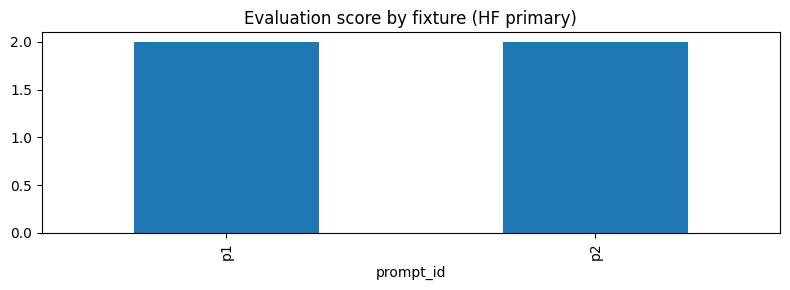

In [13]:
import pandas as pd

csv_path = ROOT / "reports" / "eval_results.csv"
if csv_path.is_file():
    df = pd.read_csv(csv_path)
    try:
        display(df.head(10))
    except NameError:
        print(df.head(10).to_string())
    try:
        import matplotlib.pyplot as plt
        fig, ax = plt.subplots(figsize=(8, 3))
        if len(df) and "score" in df.columns:
            df2 = df.copy()
            df2["score_f"] = pd.to_numeric(df2["score"], errors="coerce")
            df2.plot(x="prompt_id", y="score_f", kind="bar", ax=ax, legend=False)
            ax.set_title("Evaluation score by fixture (HF primary)")
            plt.tight_layout()
            plt.show()
    except Exception as e:
        print("Plot skipped:", e)
else:
    print("No CSV at", csv_path, "- run the evaluation subprocess cell first (with deps installed).")


**Takeaway.** The `score` column reflects **automated** heuristics in `src/evaluation/metrics.py` (whether `mock`, `hf`, or `hf_alt`)—**not** investment quality. Read `output_excerpt` against `build_recommendation_calc_payload` for the same fixture slots. With only two fixtures, treat the bar chart as **illustrative**.

---


## 13. Limitations *(critical reflection)*

**Rubric alignment:** **critical analysis** — scope, ethics, and honest assessment of what the system cannot do.

| Area | Limitation | Implication |
|------|------------|-------------|
| Capacity | 1.1B–1.5B instruct models | Nuanced planning advice is bounded; errors rise on edge cases. |
| Fine-tuning | Default `adapter_path: null` | No domain adapter unless trained and configured. |
| Data | No RAG or live feeds | Cannot ingest rates, fund facts, or tax law updates. |
| Debt model | Principal-only floor | Feasibility is illustrative, not amortisation-accurate. |
| Extraction | LLM JSON | Users may need Quick edit; retries capped by `extraction_retry_limit`. |
| Prompt techniques | Labels without prompt forks | Technique comparisons are not yet A/B tests at the prompt level. |

These limits are design boundaries, not bugs: stating them clearly satisfies typical rubric expectations on scope and ethics.

---


### File index (authoritative paths)

| Path | Role |
|------|------|
| `configs/models.yaml` | Primary and comparison HF IDs, quantization, token caps |
| `configs/dialogue.yaml` | Locale, extraction retry limit |
| `configs/training.yaml` | LoRA hyperparameters and data paths |
| `configs/evaluation.yaml` | Fixture path, metric weights, techniques list |
| `src/llm/prompts/recommend.jinja2` | Recommendation prompt template |
| `src/llm/prompts/dialogue_collect.jinja2` | Slot extraction prompt |
| `src/evaluation/fixtures/example_prompts.json` | Batch eval inputs |

---


## 14. Conclusion

**Rubric alignment:** **synthesis** — tie strengths back to design goals and evaluation evidence.

**Summary.** The submission implements a reproducible pipeline: Streamlit UI (`src/app/`), dialogue orchestration (`src/dialogue/state_machine.py`), local backends (`src/llm/`), schema-constrained recommendations (`src/finassist/schemas.py`), and principal-only debt metrics (`src/finassist/debt_calculations.py`) fed through `recommend.jinja2`.

**Main contribution.** A **hybrid** design: inspectable Python arithmetic constrains numeric claims; the LM handles strategy and wording under explicit prompt rules.

**Future work.** Train LoRA (`scripts/train_lora.py`, `configs/training.yaml`); prepend `techniques/*.txt` in code for real ablations; expand `src/evaluation/fixtures/example_prompts.json`; richer debt math (e.g. APR) behind the same payload hook.

Strengths map most clearly to **R1** (architecture) and **R5** (hybrid logic); **R6** (evaluation) should be supplemented by manual review of excerpts.

**Analysis.** The strongest analytical claims in this notebook are **conditional**: technique comparisons are **label-level** until wired (§7, §11); model quality claims need **HF** runs or §10.3; numeric **correctness** of advice is bounded by the principal-only layer (§8, §13).

---

